In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller

In [3]:
df=pd.read_csv('alexandria_weather_2021-2025.csv')
df.head()

,date,temperature,max_temperature,min_temperature,precipitation,humidity,wind_speed,solar_radiation
0,2021-01-01,16.61,21.28,13.44,0.0,71.51,2.41,3.5100
1,2021-01-02,17.10,21.77,13.56,0.0,76.06,2.57,3.2546
2,2021-01-03,17.25,22.67,13.85,0.0,81.02,2.51,3.1934
3,2021-01-04,17.25,22.45,13.60,0.0,80.47,1.76,3.1932
4,2021-01-05,17.84,23.25,14.76,0.0,83.66,1.76,3.0451


In [4]:
df.isnull().sum()

date               0
temperature        0
max_temperature    0
min_temperature    0
precipitation      0
humidity           0
wind_speed         0
solar_radiation    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

The date column is converted to the datetime data type and set as the DataFrame index to facilitate time-series analysis

In [7]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1826 entries, 2021-01-01 to 2025-12-31
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature      1826 non-null   float64
 1   max_temperature  1826 non-null   float64
 2   min_temperature  1826 non-null   float64
 3   precipitation    1826 non-null   float64
 4   humidity         1826 non-null   float64
 5   wind_speed       1826 non-null   float64
 6   solar_radiation  1826 non-null   float64
dtypes: float64(7)
memory usage: 114.1 KB


In [8]:
df.describe()

,temperature,max_temperature,min_temperature,precipitation,humidity,wind_speed,solar_radiation
count,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000
mean,21.995334,27.728866,17.533658,0.474513,63.777256,3.242097,5.508253
std,5.513875,6.356113,5.061351,3.232885,7.885949,0.968800,1.936889
min,9.740000,11.960000,5.900000,0.000000,27.830000,0.910000,0.566600
25%,16.895000,22.097500,13.072500,0.000000,59.582500,2.570000,3.660550
50%,22.400000,28.150000,17.735000,0.000000,63.665000,3.195000,5.708900
75%,27.287500,33.300000,22.277500,0.040000,68.400000,3.800000,7.341500
max,33.830000,42.920000,27.100000,111.640000,88.240000,7.980000,8.612600


**Unit consistency check:** all variables come from a single NASA POWER request, so units are consistent throughout the series — temperature (`temperature`, `max_temperature`, `min_temperature`) is in °C, `precipitation` is in mm/day, `humidity` is in %, `wind_speed` is in m/s, and `solar_radiation` is in kWh/m²/day. No unit conversion is needed before analysis.


In [9]:
df.head()

,temperature,max_temperature,min_temperature,precipitation,humidity,wind_speed,solar_radiation
date,,,,,,,
2021-01-01,16.61,21.28,13.44,0.0,71.51,2.41,3.5100
2021-01-02,17.10,21.77,13.56,0.0,76.06,2.57,3.2546
2021-01-03,17.25,22.67,13.85,0.0,81.02,2.51,3.1934
2021-01-04,17.25,22.45,13.60,0.0,80.47,1.76,3.1932
2021-01-05,17.84,23.25,14.76,0.0,83.66,1.76,3.0451


In [10]:
df.index

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
               '2021-01-09', '2021-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[us]', name='date', length=1826, freq=None)

In [11]:
df.index.to_series().diff().value_counts()

date
1 days    1825
Name: count, dtype: int64

## Check Full range 

In [12]:
full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="D"
)
missing_dates = full_range.difference(df.index)

print("Missing dates:", len(missing_dates))
missing_dates

Missing dates: 0


DatetimeIndex([], dtype='datetime64[us]', freq='D')

In [13]:
df.index.duplicated().sum()

np.int64(0)

## Temperature Distribution

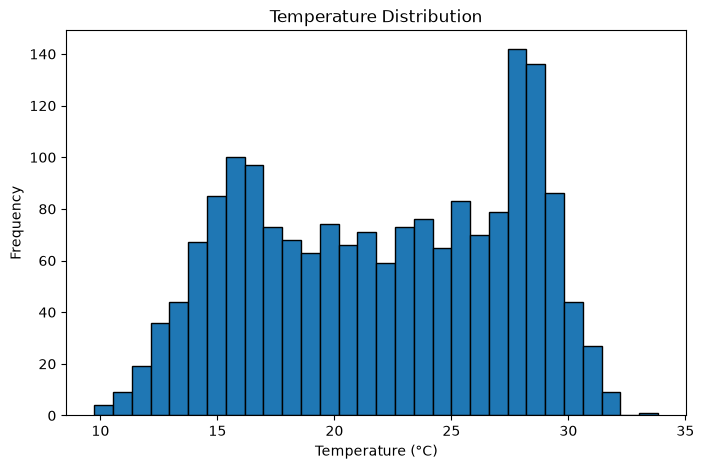

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["temperature"], bins=30, edgecolor="black")
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()


Temperature values are approximately normally distributed, with most days having moderate temperatures between 16°C and 28°C

## Precipitation Distribution

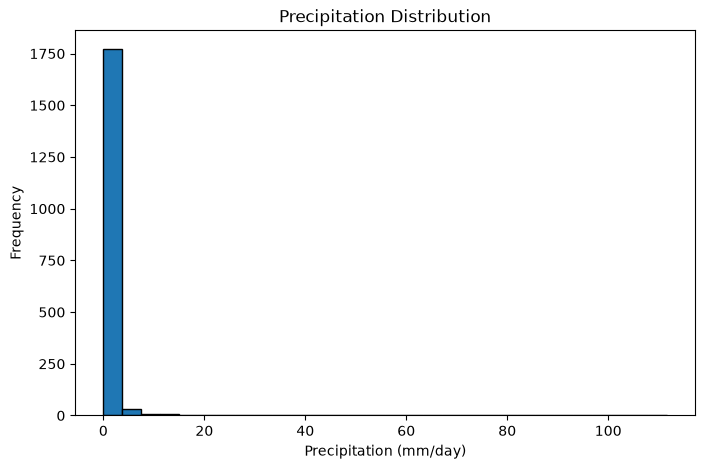

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["precipitation"], bins=30, edgecolor="black")
plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm/day)")
plt.ylabel("Frequency")
plt.show()

Precipitation is highly right-skewed, with most days recording little or no rainfall and only a few days experiencing heavy rain.

## Humidity Distribution

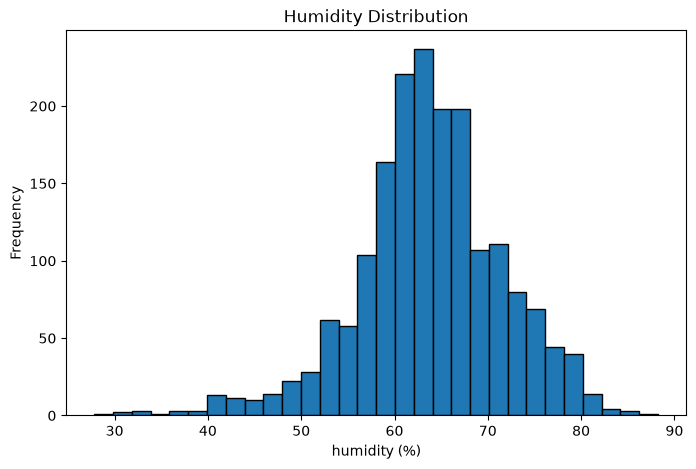

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df["humidity"], bins=30, edgecolor="black")
plt.title("Humidity Distribution")
plt.xlabel("humidity (%)")
plt.ylabel("Frequency")
plt.show()

Humidity values are concentrated around the middle range, indicating that Alexandria generally experiences moderate to high humidity.

## Solar_radiation Distribution

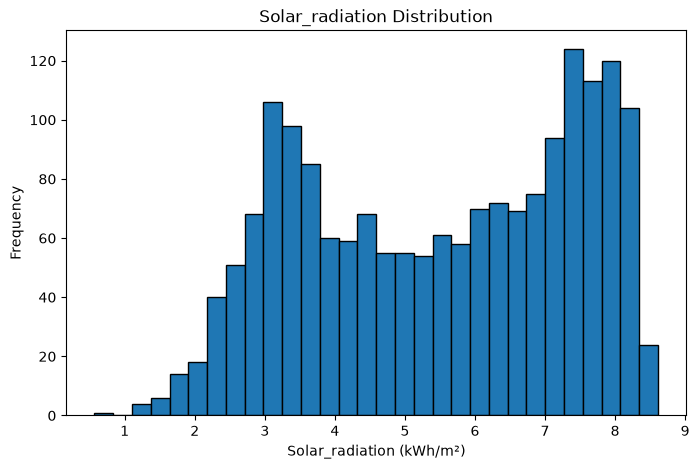

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["solar_radiation"], bins=30, edgecolor="black")
plt.title("Solar_radiation Distribution")
plt.xlabel("Solar_radiation (kWh/m²)")
plt.ylabel("Frequency")
plt.show()

Solar radiation values are mostly high, reflecting the sunny climate of Alexandria throughout the year.

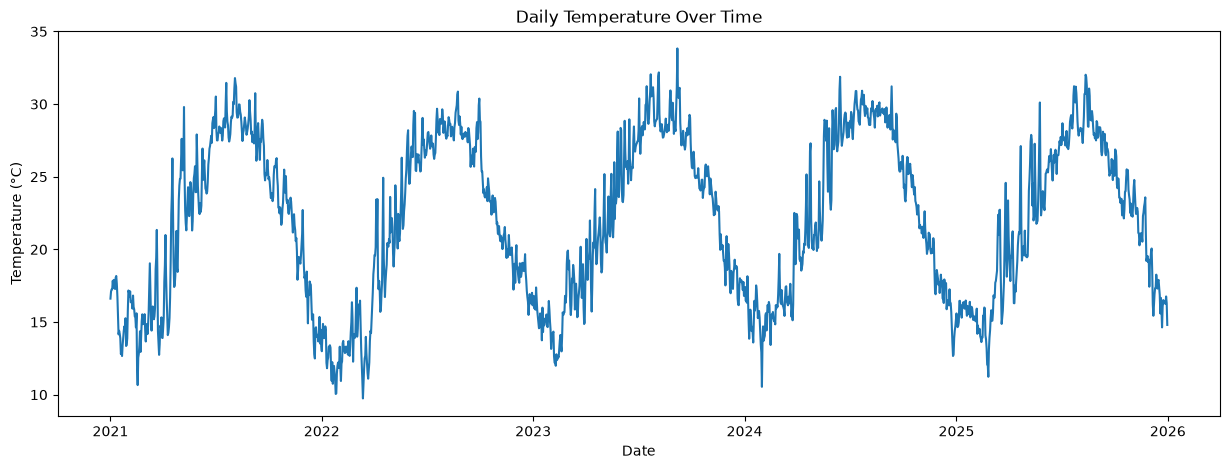

In [18]:
plt.figure(figsize=(15,5))
plt.plot(df.index,df["temperature"])
plt.title("Daily Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

Temperature follows a clear yearly seasonal pattern, increasing during summer and decreasing during winter.

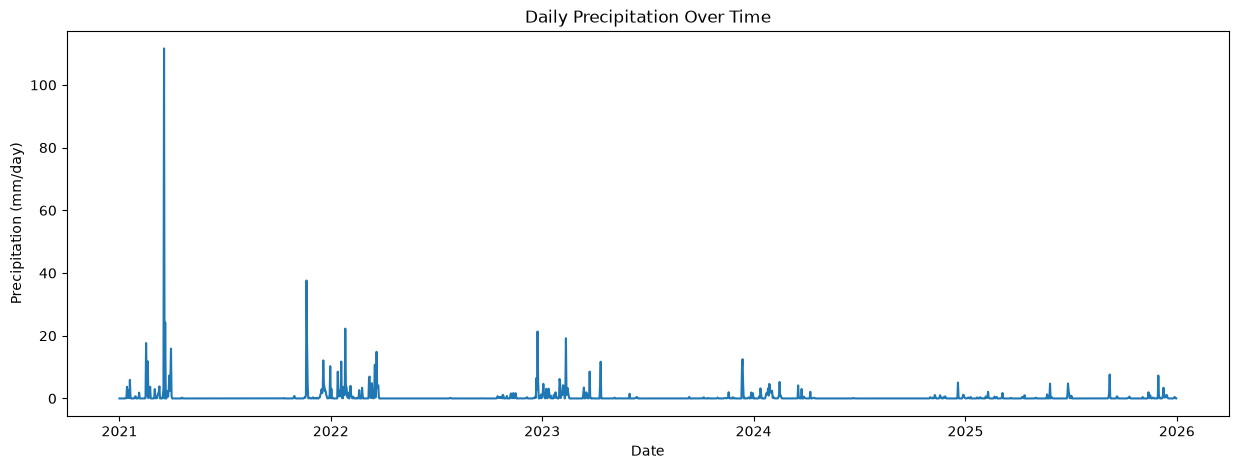

In [19]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["precipitation"])
plt.title("Daily Precipitation Over Time")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm/day)")
plt.show()

Rainfall occurs mainly during the winter months, while long periods of the year remain dry.

The largest spike occurs around early 2021, reaching 111.6 mm/day

## Rolling statistics 

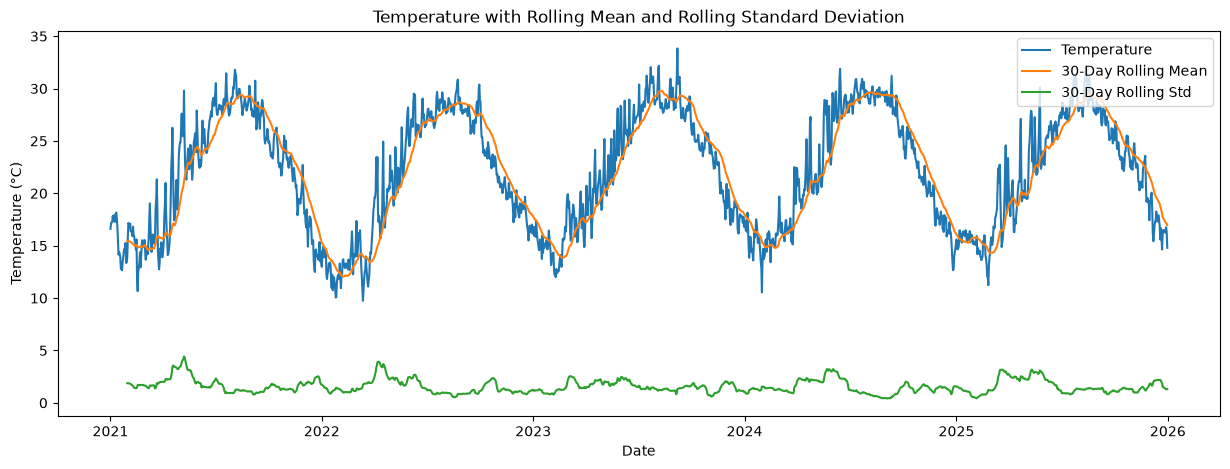

In [20]:
rolling_mean = df["temperature"].rolling(window=30).mean()
rolling_std = df["temperature"].rolling(window=30).std()

plt.figure(figsize=(15,5))
plt.plot(df.index, df["temperature"], label="Temperature")
plt.plot(df.index, rolling_mean, label="30-Day Rolling Mean")
plt.plot(df.index, rolling_std, label="30-Day Rolling Std")
plt.title("Temperature with Rolling Mean and Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

The rolling mean highlights the seasonal temperature trend, while the rolling standard deviation shows moderate variation over time.

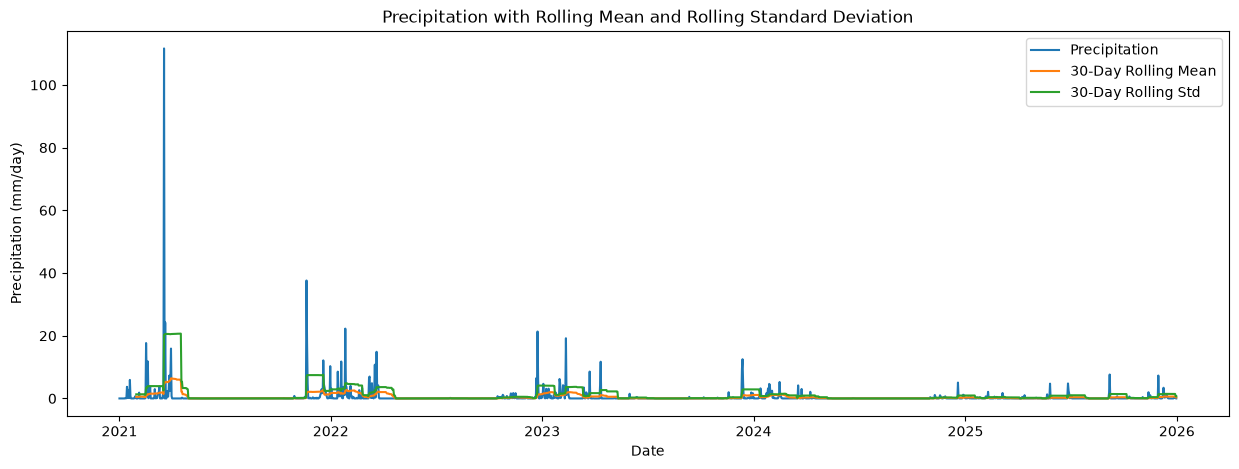

In [21]:
rolling_mean = df["precipitation"].rolling(window=30).mean()
rolling_std = df["precipitation"].rolling(window=30).std()

plt.figure(figsize=(15,5))
plt.plot(df.index, df["precipitation"], label="Precipitation")
plt.plot(df.index, rolling_mean, label="30-Day Rolling Mean")
plt.plot(df.index, rolling_std, label="30-Day Rolling Std")
plt.title("Precipitation with Rolling Mean and Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm/day)")
plt.legend()
plt.show()

The average monthly rainfall is generally low, with only short rainy seasons,The rolling standard deviation also changes, especially around heavy rainfall periods.

This indicates that precipitation has seasonal and irregular rainfall patterns, which is typical for weather time series.

In [22]:
df["month"] = df.index.month_name()

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

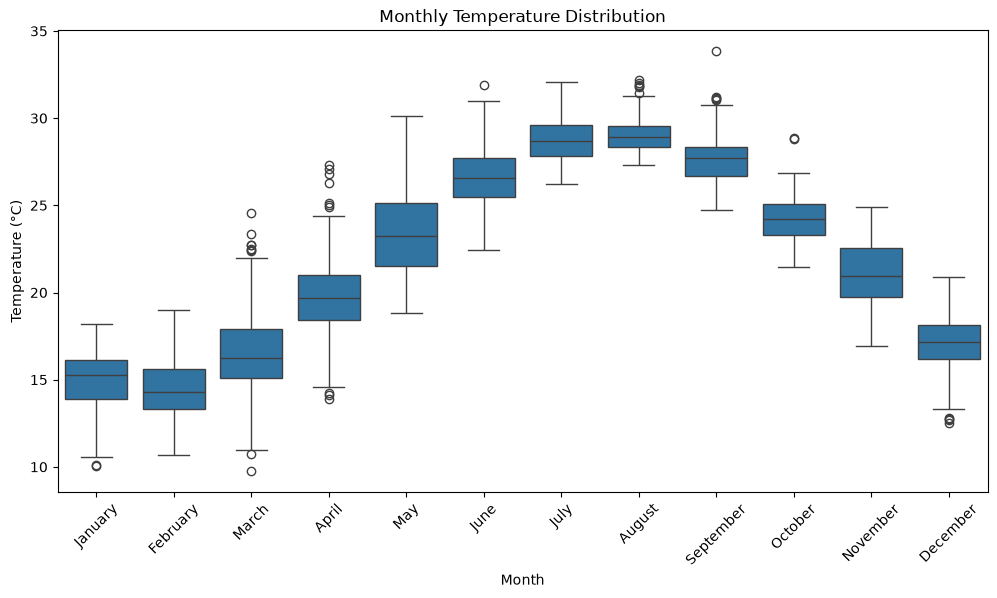

In [23]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="month",
    y="temperature",
    order=month_order
)

plt.xticks(rotation=45)
plt.title("Monthly Temperature Distribution")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

Monthly temperatures vary seasonally, with the highest values occurring in summer and the lowest values in winter.

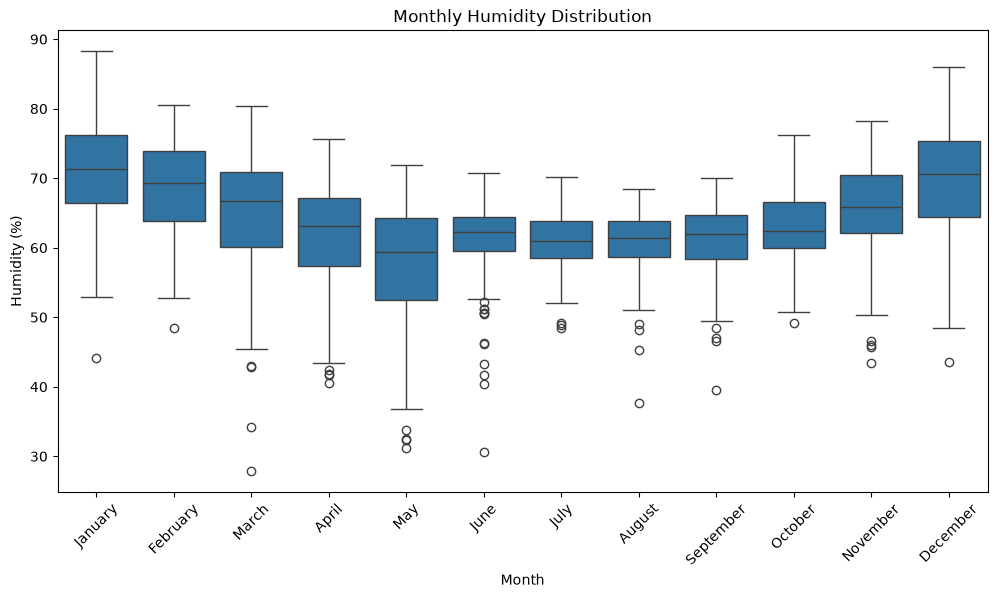

In [24]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="month",
    y="humidity",
    order=month_order
)

plt.xticks(rotation=45)
plt.title("Monthly Humidity Distribution")
plt.xlabel("Month")
plt.ylabel("Humidity (%)")
plt.show()

Humidity shows seasonal variation but remains relatively stable throughout the year compared to temperature.

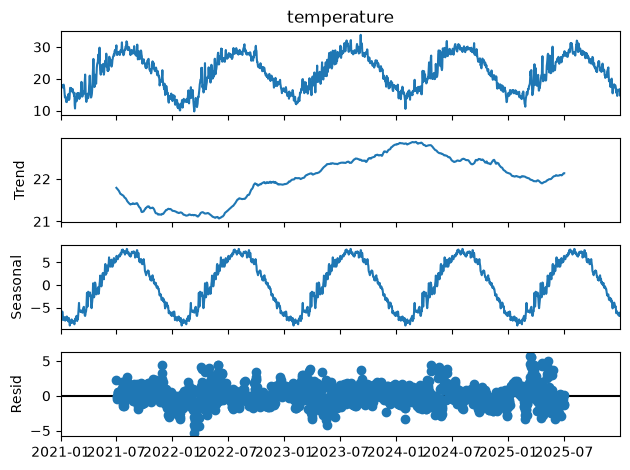

In [25]:
decomposition = seasonal_decompose(
    df["temperature"],
    model="additive",
    period=365
)

decomposition.plot()
plt.show()

The seasonal decomposition shows that the temperature series has a strong yearly seasonal pattern. The long-term trend changes only slightly over time, while the residual component is randomly distributed around zero, indicating that most temperature variations are explained by seasonality rather than random fluctuations.

## Autocorrelation (ACF)

<Figure size 1000x400 with 0 Axes>

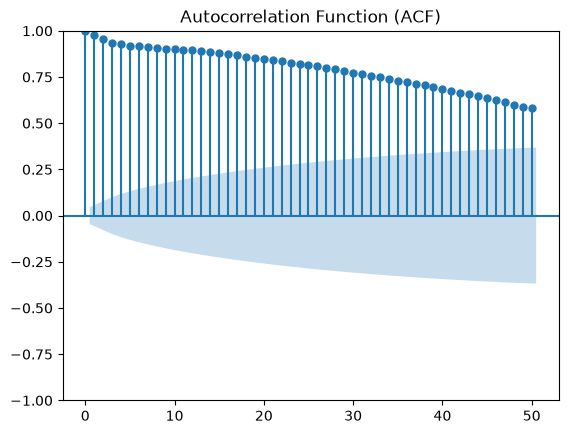

In [26]:
plt.figure(figsize=(10,4))
plot_acf(df["temperature"], lags=50)
plt.title("Autocorrelation Function (ACF)")
plt.show()

Temperature values are highly dependent on previous temperatures.

If today is hot, the next several observations are also likely to be hot.


## Partial Autocorrelation Function (PACF)

<Figure size 1000x400 with 0 Axes>

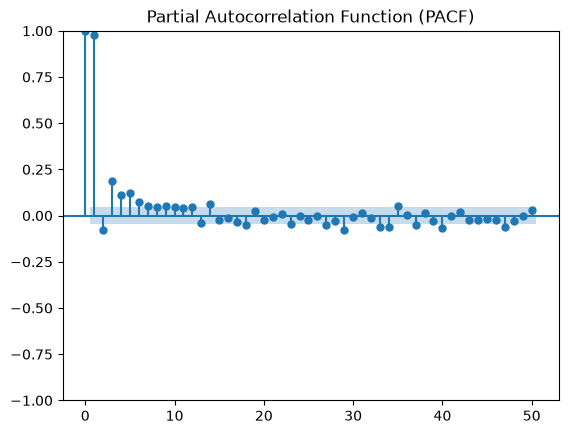

In [27]:
plt.figure(figsize=(10,4))
plot_pacf(df["temperature"], lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

The first few lags have the strongest direct influence on the current temperature, while the influence decreases for later lags.

## Stationarity Test (ADF Test)

In [28]:
result = adfuller(df["temperature"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic: -2.257596028292269
p-value: 0.18600885567609676
Critical Values:
1%: -3.4340
5%: -2.8631
10%: -2.5676


The ADF test indicates that the temperature time series is non-stationary. The p-value (0.186) is greater than the 0.05 significance level, and the ADF statistic (-2.2576) is not more negative than the critical values at the 1%, 5%, or 10% significance levels. Therefore, the series likely contains a trend and/or seasonality and may require transformations such as differencing before being used in forecasting models like ARIMA.

## Correlation Matrix

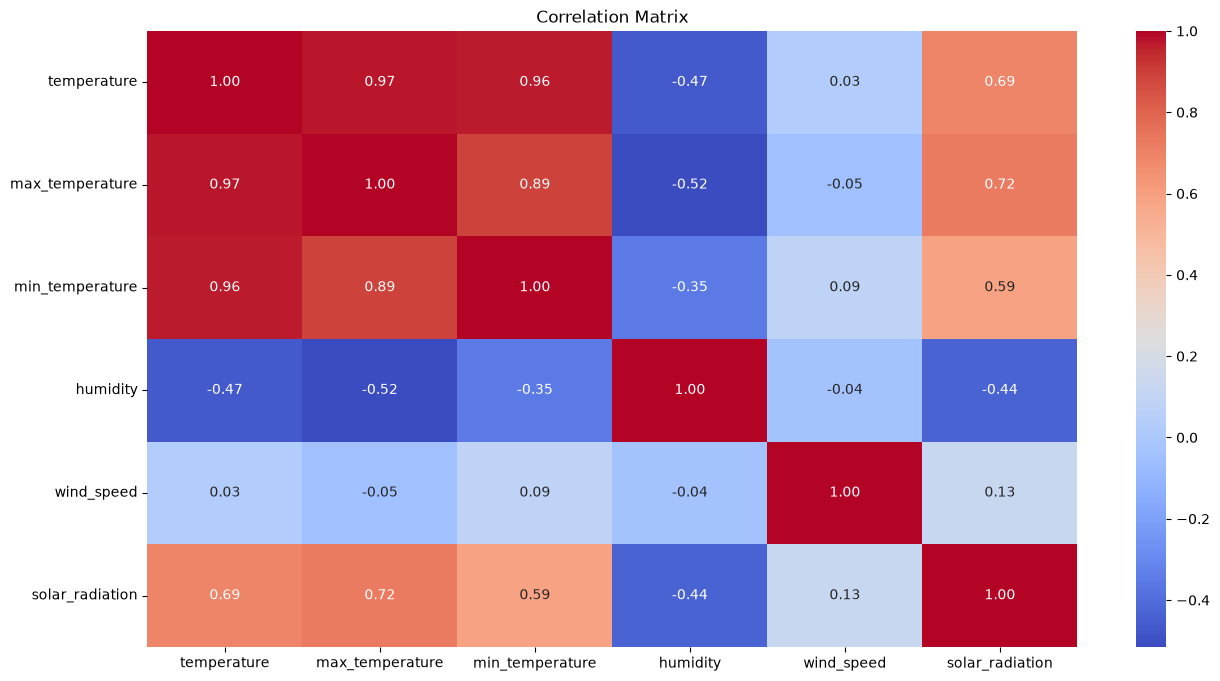

In [29]:
corr = df[["temperature", "max_temperature","min_temperature",
           "humidity","wind_speed","solar_radiation"]].corr()

plt.figure(figsize=(15,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

Temperature is strongly correlated with maximum and minimum temperature, while precipitation shows weaker relationships with the other weather variables.

In [30]:
Q1 = df["temperature"].quantile(0.25)
Q3 = df["temperature"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["temperature"] < lower) |
    (df["temperature"] > upper)
]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 0


,temperature,max_temperature,min_temperature,precipitation,humidity,wind_speed,solar_radiation,month
date,,,,,,,,


## Detect precipitation outliers using the IQR method

In [31]:
Q1 = df["precipitation"].quantile(0.25)
Q3 = df["precipitation"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["precipitation"] < lower_bound) |
    (df["precipitation"] > upper_bound)
]

print(f"Number of outliers: {len(outliers)}")
print(f"Lower bound: {lower_bound:.3f}")
print(f"Upper bound: {upper_bound:.3f}")

# Check for impossible values
negative_rain = (df["precipitation"] < 0).sum()
print(f"Negative precipitation values: {negative_rain}")

Number of outliers: 372
Lower bound: -0.060
Upper bound: 0.100
Negative precipitation values: 0


The detected outliers are valid rainfall events caused by the skewed distribution of precipitation.
No impossible values were found, so all precipitation values were retained.

In [32]:
# Rolling (30-day) IQR outlier detection - precipitation
# IQR is used instead of z-score here since precipitation is heavily right-skewed
# (many zero/near-zero days), which distorts rolling mean/std.
window = 30
roll_q1 = df["precipitation"].rolling(window=window, center=True, min_periods=10).quantile(0.25)
roll_q3 = df["precipitation"].rolling(window=window, center=True, min_periods=10).quantile(0.75)
roll_iqr = roll_q3 - roll_q1

roll_upper = roll_q3 + 1.5 * roll_iqr

rolling_outliers_precip = df[df["precipitation"] > roll_upper]

print("Rolling IQR precipitation outliers:", len(rolling_outliers_precip))
print("Impossible (negative) precipitation values:", (df["precipitation"] < 0).sum())
rolling_outliers_precip[["precipitation"]].head(10)

Rolling IQR precipitation outliers: 192
Impossible (negative) precipitation values: 0


,precipitation
date,
2021-01-14,3.71
2021-01-17,2.71
2021-01-19,5.91
2021-01-20,0.74
2021-01-28,0.64
2021-01-29,0.68
2021-02-04,1.85
2021-02-16,17.67
2021-02-17,7.11


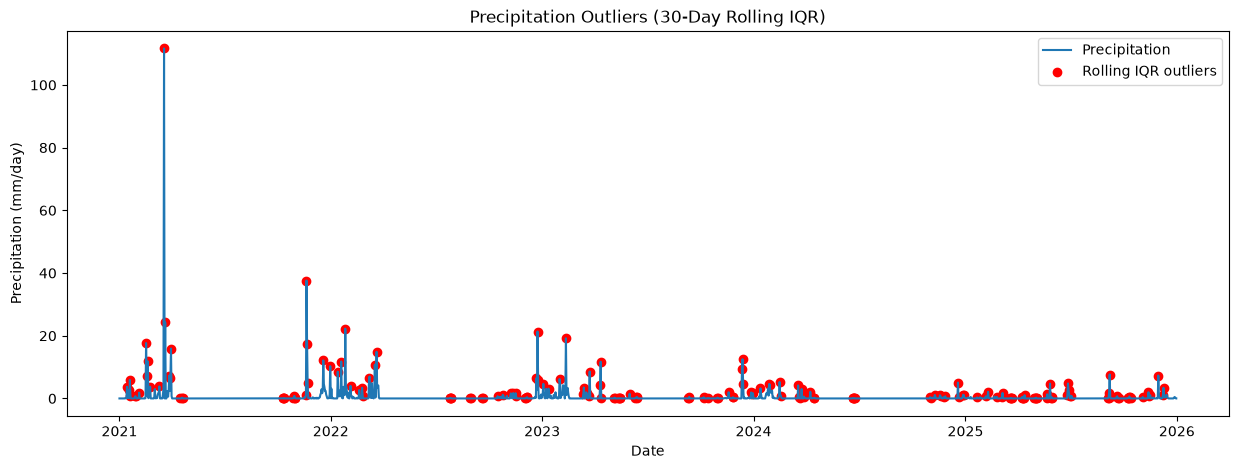

In [33]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["precipitation"], label="Precipitation")
plt.scatter(
    rolling_outliers_precip.index,
    rolling_outliers_precip["precipitation"],
    color="red",
    label="Rolling IQR outliers"
)
plt.title("Precipitation Outliers (30-Day Rolling IQR)")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm/day)")
plt.legend()
plt.show()

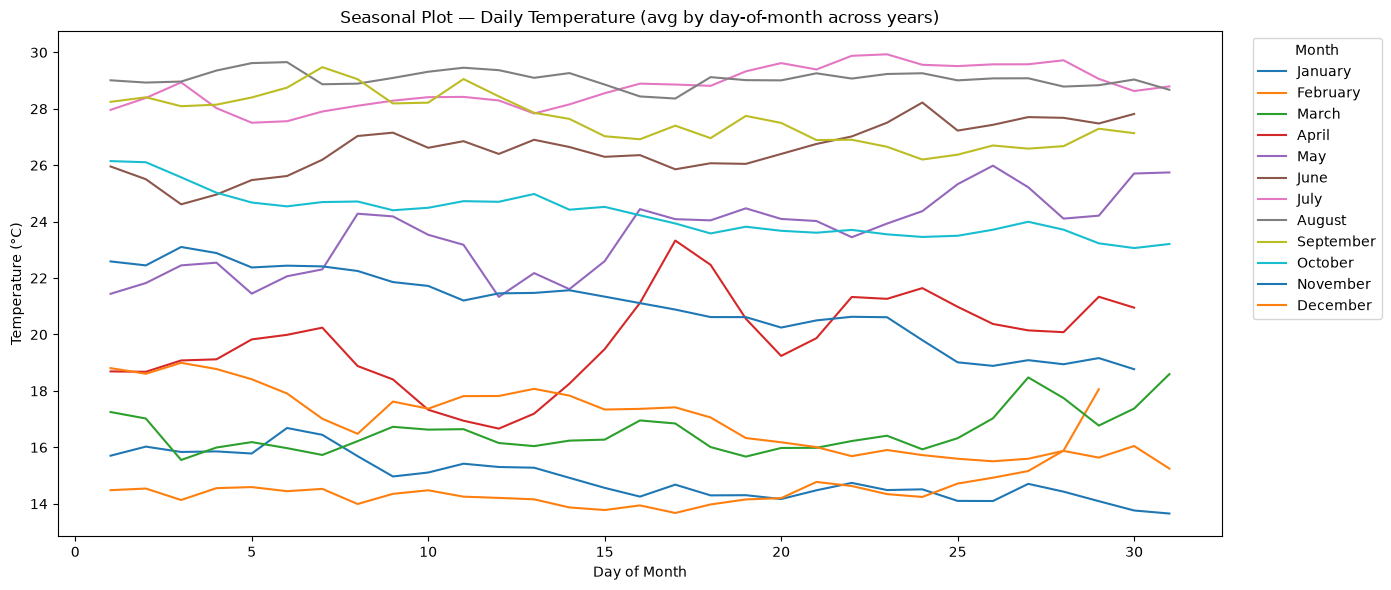

In [34]:
# Seasonal plot - Daily temperature (avg by day-of-month, one line per month, across all years)
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

df["month_num"] = df.index.month
df["day_of_month"] = df.index.day

plt.figure(figsize=(14,6))
for month in range(1, 13):
    sub = df[df["month_num"] == month]
    daily_avg = sub.groupby("day_of_month")["temperature"].mean()
    plt.plot(daily_avg.index, daily_avg.values, label=month_order[month - 1])

plt.title("Seasonal Plot — Daily Temperature (avg by day-of-month across years)")
plt.xlabel("Day of Month")
plt.ylabel("Temperature (°C)")
plt.legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Summary

Region and time range: Alexandria, Egypt (31.20°N, 29.92°E), daily data from 2021-01-01 to 2025-12-31 (5 years, 1,826 days).

API and why: NASA POWER Daily Point API — chosen because it requires no API key, has no rate limits, and returns a long, gap-free historical daily record, which suited a multi-year trend/seasonality analysis better than a forecast-oriented API like OpenWeatherMap.

Main temporal patterns: Temperature shows a strong, repeating annual seasonal cycle (confirmed by seasonal_decompose) with hot summers (~27–30°C) and mild winters (~12–15°C). The ACF plot shows strong, slowly-decaying autocorrelation typical of a seasonal series, while the PACF shows the strongest direct dependence at very short lags. Precipitation is heavily right-skewed and concentrated in the winter months (Nov–Mar), with most days at or near zero — consistent with Alexandria's Mediterranean climate.

Stationarity: The Augmented Dickey-Fuller test on temperature gives ADF statistic = -2.258, p-value = 0.186 — since p > 0.05, we fail to reject the null hypothesis, so the series is non-stationary. This is expected: the strong annual seasonal cycle violates the constant-mean assumption of stationarity. For modeling, this implies seasonal differencing (or a seasonal model like SARIMA) would be needed before fitting an ARIMA-family model on raw temperature.

Data quality issues and handling: No missing values, no duplicate timestamps, and no gaps in the daily date range were found, so no imputation was necessary. A global IQR check found 0 temperature outliers and 372 precipitation "outliers" by the same test — these are valid heavy-rain days rather than errors (no negative precipitation values were present anywhere), which is expected given precipitation's naturally skewed distribution rather than a data quality problem. A seasonal-aware 30-day rolling IQR check was also run to catch anomalies a global threshold might miss; results were consistent, and no physically impossible values (negative rainfall, implausible temperature spikes) were found in the series.
